# Patient Simulator Comparison
In this notebook we compare different implementations of patient simulators to our own implementation. The simulators were ran on multiple acted conversations, scores are mainly aggregated. We compare rather default personas here, since not all simulators allow for parametrizing a non-default patient behavior.

In [1]:
%load_ext autoreload
%autoreload 2

import os

os.chdir("..")

## Experiment Completeness Check

In [2]:
from hydra import initialize_config_dir, compose
from hydra.core.global_hydra import GlobalHydra
from omegaconf import OmegaConf
from patient_simulator.misc.utils import check_experiment_completeness

config_name = "patient_comparison_default"

GlobalHydra.instance().clear()
initialize_config_dir(
    config_dir=os.path.abspath("configs/experiment"), job_name="notebook"
)
cfg = compose(config_name=config_name)
GlobalHydra.instance().clear()

check_experiment_completeness(
    OmegaConf.to_container(cfg, resolve=True), delete_incomplete=False
)

/tmp/ipykernel_3401569/523335940.py:9: UserWarning: 
The version_base parameter is not specified.
Please specify a compatability version level, or None.
Will assume defaults for version 1.1
  initialize_config_dir(
/home/mschlager/patient-simulator/.venv/lib/python3.12/site-packages/omegaconf/grammar_visitor.py:253: UserWarning: In the sequence `GOOGLE_CLOUD_API_KEY,` some elements are missing: please replace them with empty quoted strings. See https://github.com/omry/omegaconf/issues/572 for details.
  warnings.warn(


Experiment : results/patient_comparison_default
Conversations: 22  |  Patient configs: 21  |  Total: 462

── Simulation (OK)

── Turn count (OK)

── Evaluation (OK)


In [3]:
import pandas as pd
import logging

from patient_simulator.misc.plotting import (
    plot_dist_by_category,
    plot_stacked_bar,
    plot_category_fraction,
    plot_hexaco_reconstructed_grouped_bar,
    plot_disclosure_curve,
    plot_combined_metric_boxplots,
)

logging.getLogger().setLevel(logging.WARNING)

# Evaluate Aggregated Metrics

In [19]:
res = pd.read_csv(f"results/{config_name}/all_conversations.csv")

# replace single quotes with double quotes in "relevance_distribution" and "diversity_distribution" columns
res["relevance_distribution"] = res["relevance_distribution"].str.replace("'", '"')
res["profile_fidelity_distribution"] = res["profile_fidelity_distribution"].str.replace(
    "'", '"'
)

In [ ]:
# create a new column "patient_disp_name" by mapping patien name according to a dict
mapping = {
    "VirtualPatient": "VirtualPatient",
    "StateAwarePatient": "StateAwarePatient",
    "PatientSimPatient_persplain_cefrB_dazednormal_recallhigh": "PatientSim",
    "CraftMDPatient": "CraftMD",
    "AgentClinicPatient_nobias": "AgentClinic",
    "PatientsWithPersonality_H2_E1_X1_A2_C2_O1_LB": "PatientsWithPersonality",
    "BaselinePatient": "Human Rephrase",
    "RealPatient": "Human Actor",
    # "PatientsWithPersonality_H1_E1_X2_A1_C1_O1_LB": "PatientsWithPersonality_calm",
}

res["patient_disp_name"] = res["patient_name"].map(mapping)
# filter out all rows where patient_disp_name is null
res = res[~res["patient_disp_name"].isnull()]

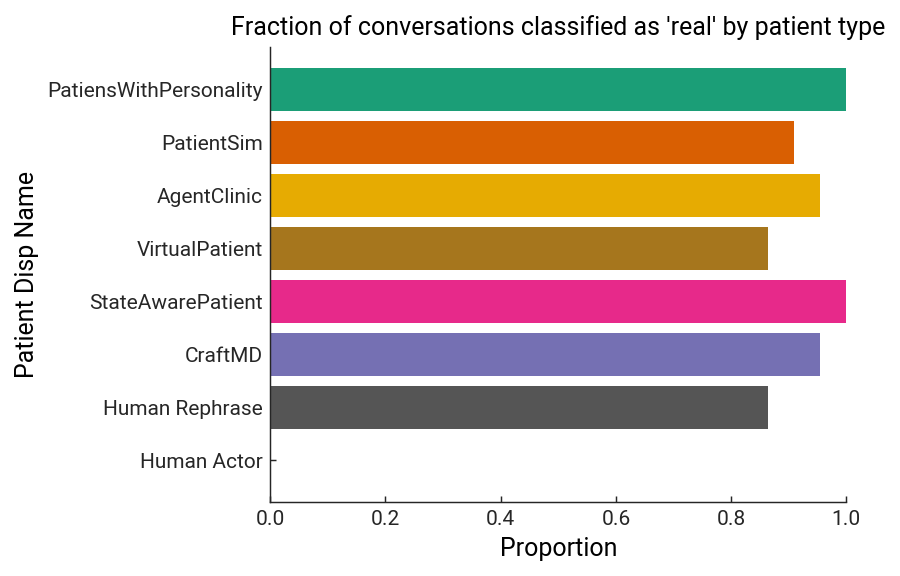

In [21]:
plot_category_fraction(
    res,
    category="patient_disp_name",
    value_col="judge_classification",
    target_value="simulated",
    title="Fraction of conversations classified as 'real' by patient type",
);

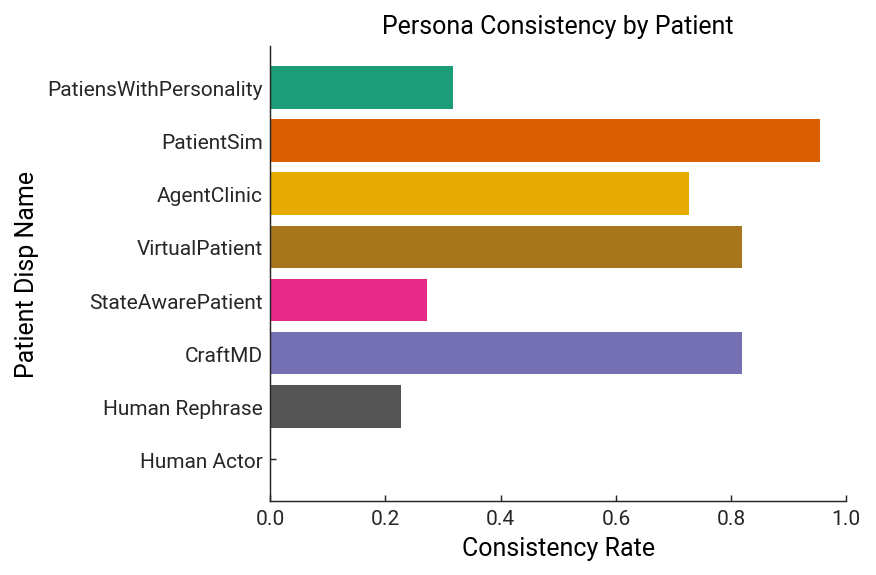

,patient_disp_name,fraction,error
2,Human Actor,0.000000,0.0
3,Human Rephrase,0.227273,0.0
1,CraftMD,0.818182,0.0
6,StateAwarePatient,0.272727,0.0
7,VirtualPatient,0.818182,0.0
0,AgentClinic,0.727273,0.0
5,PatientSim,0.954545,0.0
4,PatiensWithPersonality,0.318182,0.0


In [22]:
plot_category_fraction(
    res,
    category="patient_disp_name",
    value_col="persona_consistency",
    target_value="Consistent",
    title="Persona Consistency by Patient",
    x_label="Consistency Rate",
)

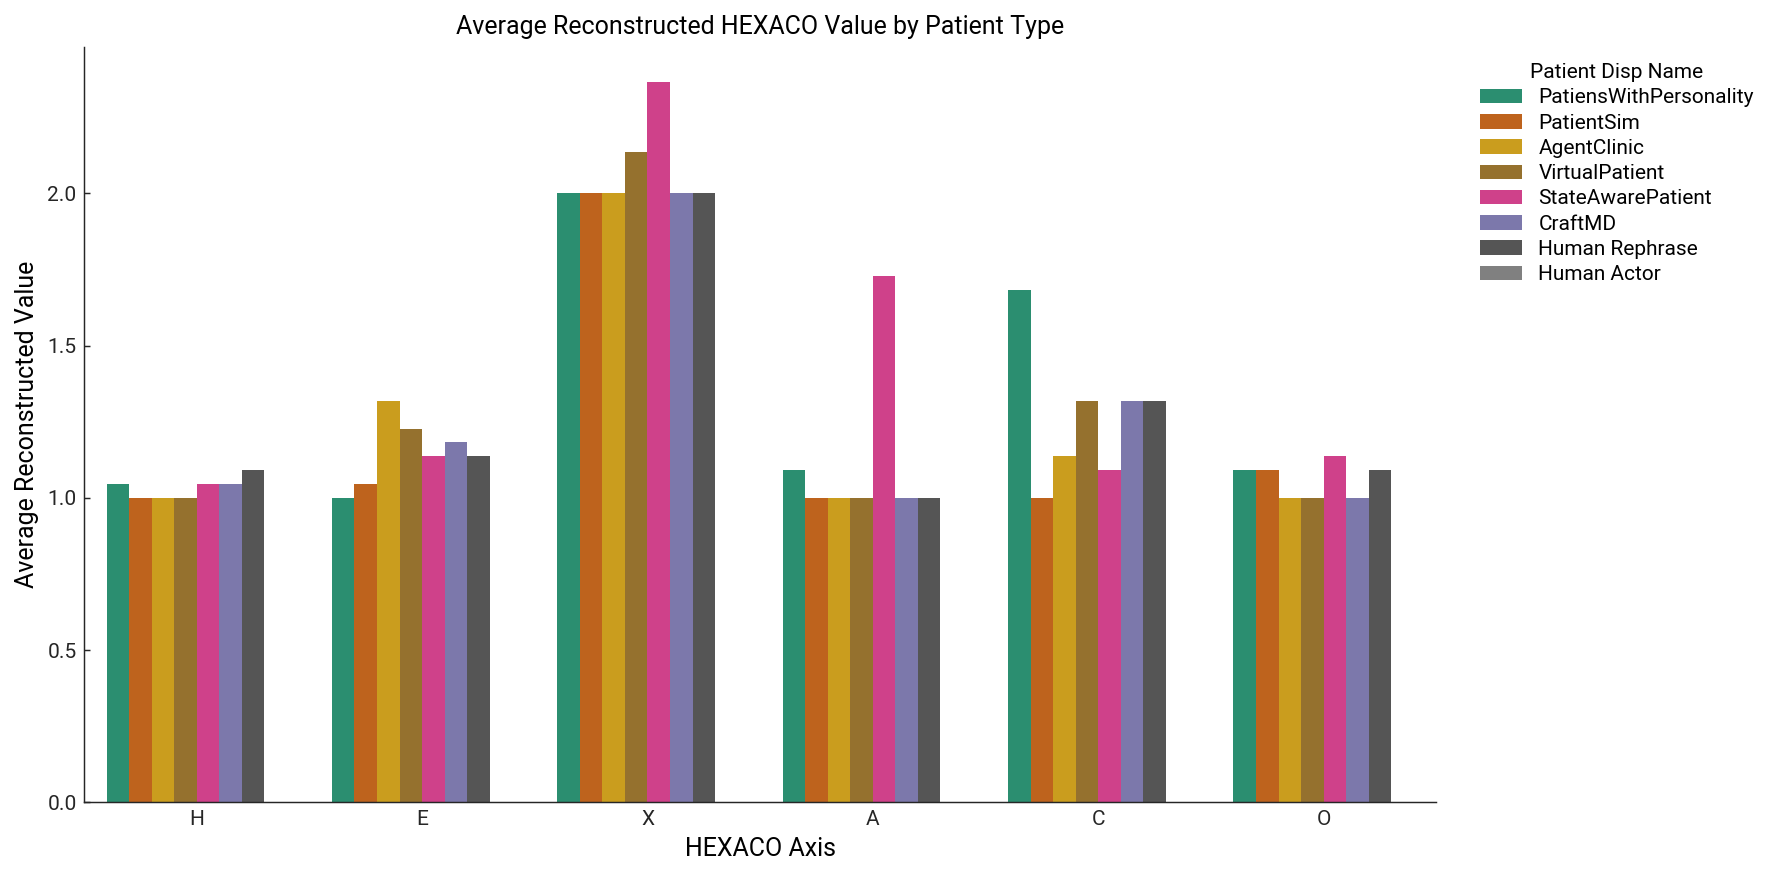

,patient_disp_name,personality_reconstructed_H,personality_reconstructed_E,personality_reconstructed_X,personality_reconstructed_A,personality_reconstructed_C,personality_reconstructed_O
0,AgentClinic,1.000000,1.318182,2.000000,1.000000,1.136364,1.000000
1,CraftMD,1.045455,1.181818,2.000000,1.000000,1.318182,1.000000
2,Human Actor,NaN,NaN,NaN,NaN,NaN,NaN
3,Human Rephrase,1.090909,1.136364,2.000000,1.000000,1.318182,1.090909
4,PatiensWithPersonality,1.045455,1.000000,2.000000,1.090909,1.681818,1.090909
5,PatientSim,1.000000,1.045455,2.000000,1.000000,1.000000,1.090909
6,StateAwarePatient,1.045455,1.136364,2.363636,1.727273,1.090909,1.136364
7,VirtualPatient,1.000000,1.227273,2.136364,1.000000,1.318182,1.000000


In [23]:
plot_hexaco_reconstructed_grouped_bar(
    res,
    category="patient_disp_name",
)

In [24]:
res

,total_steps,relevance_distribution,realism_content_similarity,realism_style_similarity,persona_consistency,personality_reconstructed_H,personality_reconstructed_E,personality_reconstructed_X,personality_reconstructed_A,personality_reconstructed_C,...,judge_symptom_realism,judge_information_control,judge_style_realism,judge_justification,judge_p_real,judge_classification,mean_token_count_doctor,mean_token_count_patient_sim,mean_token_count_patient_real,patient_disp_name
0,23,"{""Direct Answer"": 20, ""Tangential"": 2, ""Irrele...",1.000000,0.260870,Inconsistent,1.0,1.0,2.0,1.0,1.0,...,2.0,2.0,2.0,"The dialogue feels artificial and scripted, pa...",0.20,simulated,21.783,11.870,12.348,Human Rephrase
2,23,"{""Direct Answer"": 22, ""Tangential"": 1}",0.391304,0.043478,Consistent,1.0,1.0,2.0,1.0,1.0,...,2.0,2.0,1.0,The dialogue is highly artificial and lacks th...,0.20,simulated,25.043,16.913,12.348,PatientSim
3,23,"{""Direct Answer"": 22, ""Irrelevant/Evasive"": 1}",0.347826,0.000000,Consistent,1.0,1.0,2.0,1.0,1.0,...,3.0,3.0,2.0,While the patient's symptoms (shortness of bre...,0.30,simulated,22.739,13.174,12.348,CraftMD
4,23,"{""Direct Answer"": 22, ""Irrelevant/Evasive"": 1}",0.434783,0.043478,Consistent,1.0,2.0,2.0,1.0,1.0,...,3.0,3.0,2.0,The conversation feels highly scripted and unn...,0.20,simulated,23.739,17.696,12.348,VirtualPatient
5,23,"{""Irrelevant/Evasive"": 12, ""Direct Answer"": 11}",0.217391,0.086957,Consistent,1.0,1.0,2.0,3.0,1.0,...,2.0,1.0,1.0,This transcript is clearly a technical simulat...,0.05,simulated,24.783,19.739,12.348,StateAwarePatient
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
479,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,20.600,7.300,7.300,Human Actor
480,38,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,37.053,10.316,10.316,Human Actor
481,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,27.400,15.050,15.050,Human Actor
482,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,19.000,17.312,17.312,Human Actor


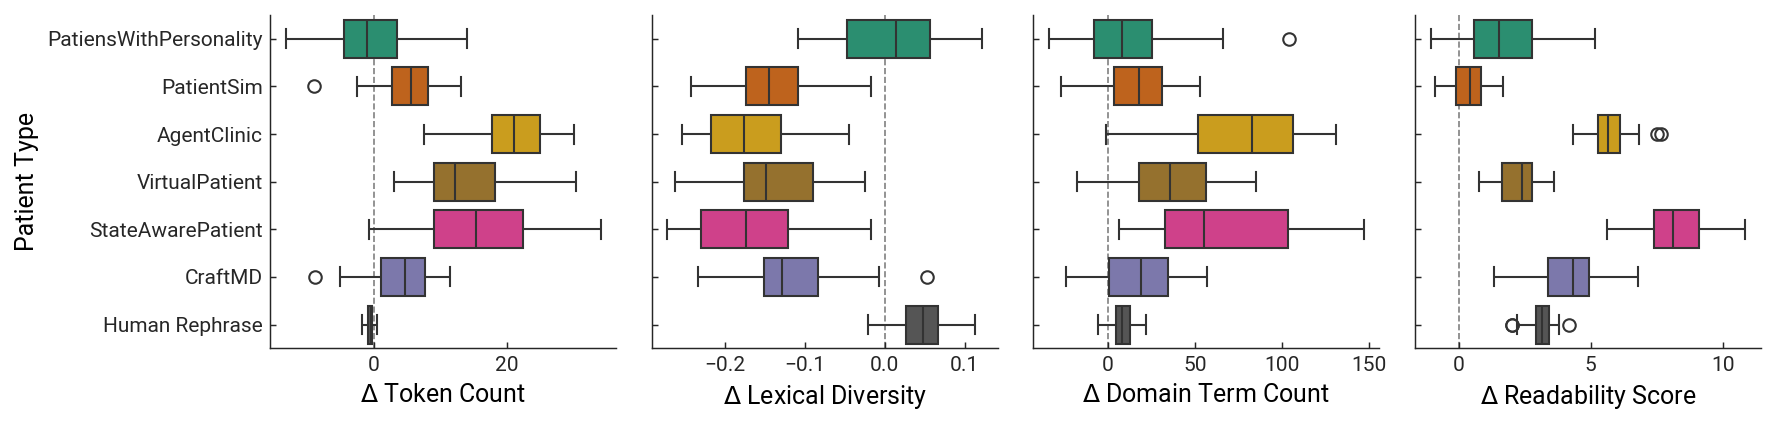

In [27]:
metrics = [
    "mean_token_count_patient",
    "lexical_diversity",
    "domain_term_count",
    "readability_score",
]

for metric in metrics:
    res[f"{metric}_diff"] = res[f"{metric}_sim"] - res[f"{metric}_real"]

metric_display_names = {
    "mean_token_count_patient": "Token Count",
    "lexical_diversity": "Lexical Diversity",
    "domain_term_count": "Domain Term Count",
    "readability_score": "Readability Score",
}

plot_combined_metric_boxplots(
    res[(res["patient_disp_name"] != "Human Actor")],
    metrics=metrics,
    category="patient_disp_name",
    metric_suffix="_diff",
    metric_display_names=metric_display_names,
    save_as="sim_comp_combined_metrics",
);

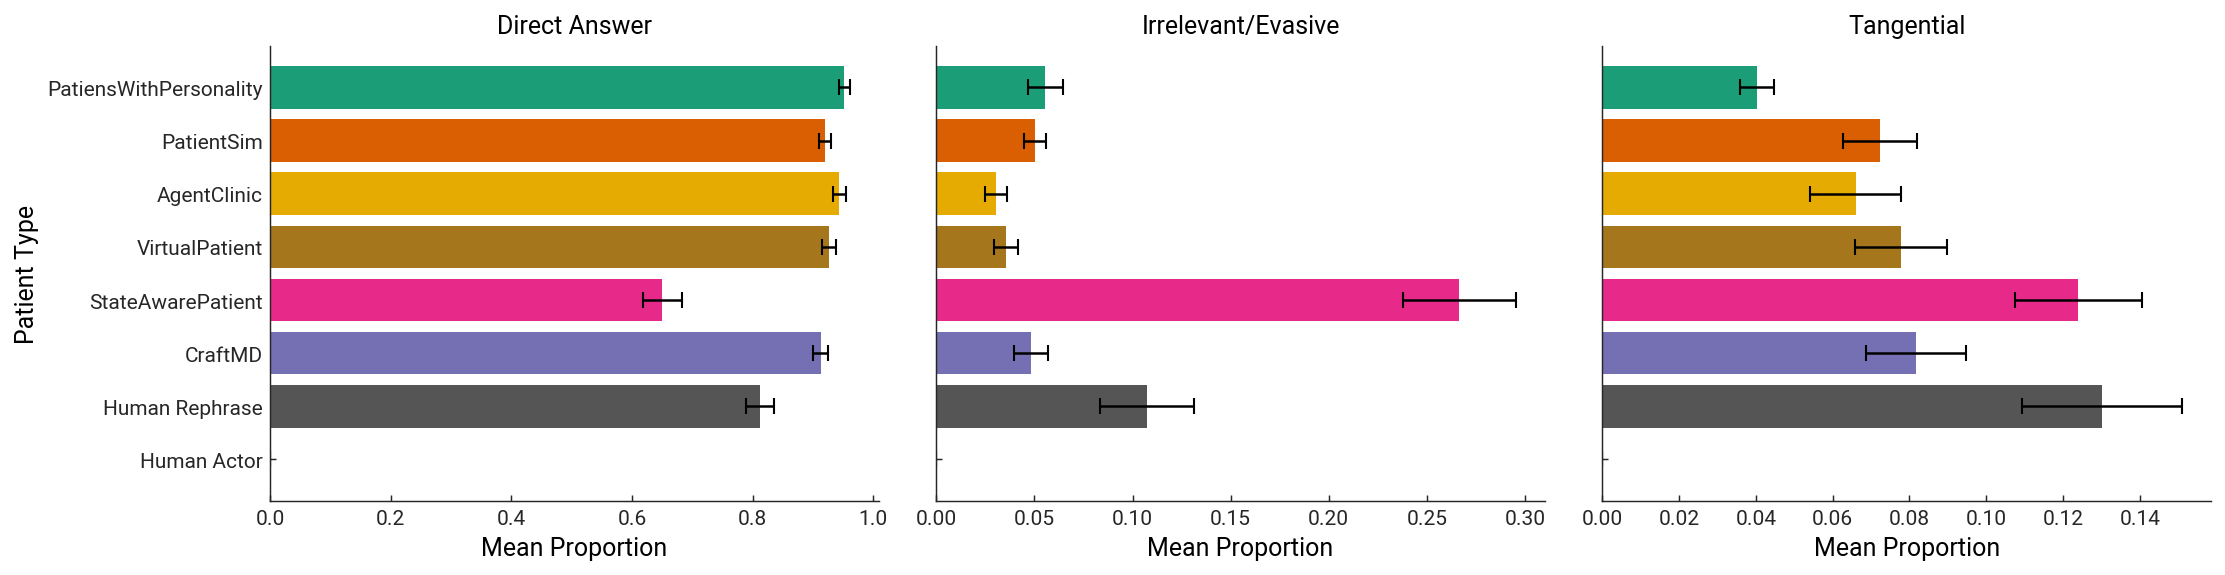

In [ ]:
plot_dist_by_category(
    res,
    category="patient_disp_name",
    valid_categories=["Direct Answer", "Irrelevant/Evasive", "Tangential"],
);

In [ ]:
plot_dist_by_category(
    res,
    category="patient_disp_name",
    distribution_col="profile_fidelity_distribution",
)

## Sentiment Scores


  CraftMD: missing 0.00%
  Human Actor: missing 100.00%
  PatiensWithPersonality: missing 0.15%
  PatientSim: missing 0.01%
  StateAwarePatient: missing 13.39%
  VirtualPatient: missing 0.00%


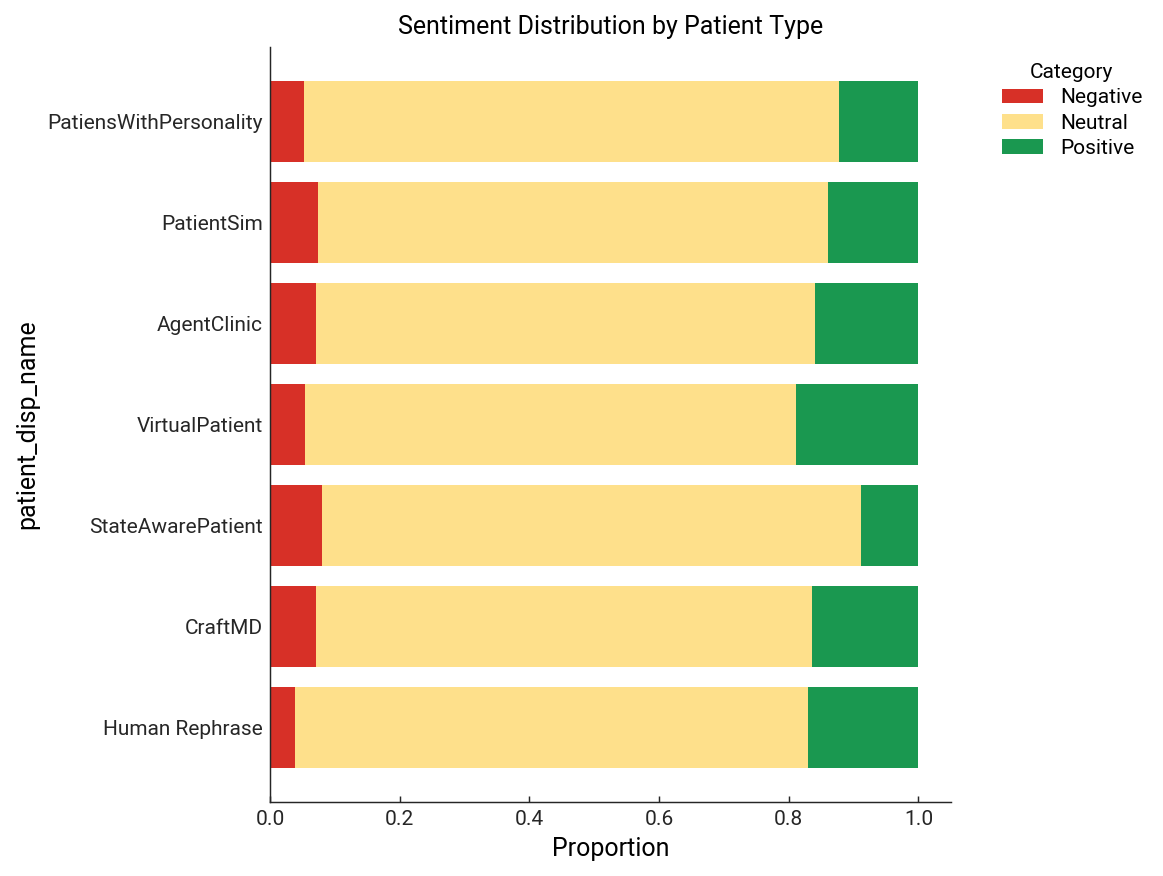

In [ ]:
plot_stacked_bar(
    res,
    value_cols=[
        "mean_sentiment_neg_sim",
        "mean_sentiment_neu_sim",
        "mean_sentiment_pos_sim",
    ],
    value_dispnames=[
        "Negative",
        "Neutral",
        "Positive",
    ],
    category="patient_disp_name",
    title="Sentiment Distribution by Patient Type",
    sort_by="mean_sentiment_neg_sim",
);

## Information Control Metrics

Metrics derived from per-turn fact extraction: how quickly and completely patients disclose case information, how well they respond to direct questions, and how much they volunteer unprompted.

In [ ]:
res["patient_disp_name"].unique()

array(['Human Rephrase', 'PatientSim', 'CraftMD', 'VirtualPatient',
       'StateAwarePatient', 'AgentClinic', 'PatiensWithPersonality',
       'Human Actor'], dtype=object)

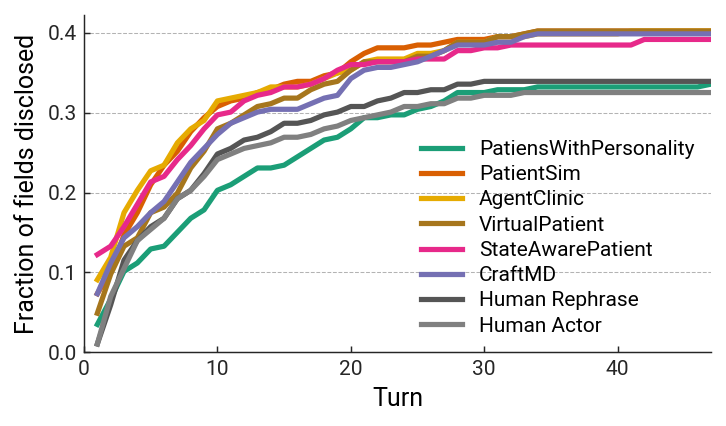

In [ ]:
plot_disclosure_curve(
    res,
    group_col="patient_disp_name",
    show_sd=False,
    save_as="sim_comp_disclosure_curve",
);

In [ ]:
from patient_simulator.misc.plotting import PATIENT_TYPE_ORDER

DISC_METRICS = [
    ("median_ttf", "Median TTF", "max"),
    ("disclosure_auc", "Disclosure AUC", "min"),
    ("pdp_f1_mean", "PDP F1", "max"),
    ("pdp_precision_mean", "PDP Precision", "max"),
    ("pdp_recall_mean", "PDP Recall", "max"),
    ("unprompted_leakage_rate", "Unprompted Leakage", "min"),
]

_order = {pt: i for i, pt in enumerate(PATIENT_TYPE_ORDER)}
patient_types = sorted(
    res["patient_disp_name"].dropna().unique(),
    key=lambda x: (_order.get(x, len(PATIENT_TYPE_ORDER)), x),
)
col_names = [label for _, label, _ in DISC_METRICS]

means = pd.DataFrame(index=patient_types, columns=col_names, dtype=float)
sems = pd.DataFrame(index=patient_types, columns=col_names, dtype=float)

for pt in patient_types:
    sub = res[res["patient_disp_name"] == pt]
    for col, label, _ in DISC_METRICS:
        means.loc[pt, label] = sub[col].mean()
        sems.loc[pt, label] = sub[col].sem()


def fmt(v):
    return f"{v:.2f}"


display_df = means.map(fmt) + " ± " + sems.map(fmt)


def _highlight_best(s):
    styles = pd.DataFrame("", index=s.index, columns=s.columns)
    for _, label, direction in DISC_METRICS:
        best_idx = (
            means[label].idxmin() if direction == "min" else means[label].idxmax()
        )
        best_val = means.loc[best_idx, label]
        best_sem = sems.loc[best_idx, label]
        mask = (means[label] - best_val).abs() <= best_sem
        styles.loc[mask, label] = "font-weight: bold"
    return styles


display_df.style.apply(_highlight_best, axis=None).set_caption(
    "Disclosure Metrics by Patient Type (mean ± SEM; bold = best or within its SEM)"
)

,Median TTF,Disclosure AUC,PDP F1,PDP Precision,PDP Recall,Unprompted Leakage
PatiensWithPersonality,9.68 ± 1.44,0.23 ± 0.02,0.36 ± 0.03,0.41 ± 0.03,0.34 ± 0.03,0.13 ± 0.04
PatientSim,6.05 ± 0.90,0.31 ± 0.02,0.38 ± 0.03,0.43 ± 0.03,0.38 ± 0.03,0.25 ± 0.03
AgentClinic,5.93 ± 0.98,0.31 ± 0.02,0.37 ± 0.02,0.41 ± 0.03,0.38 ± 0.02,0.20 ± 0.02
VirtualPatient,7.82 ± 1.06,0.29 ± 0.02,0.38 ± 0.04,0.42 ± 0.04,0.38 ± 0.03,0.19 ± 0.04
StateAwarePatient,6.23 ± 1.30,0.30 ± 0.02,0.32 ± 0.03,0.37 ± 0.03,0.31 ± 0.03,0.33 ± 0.05
CraftMD,8.64 ± 1.38,0.29 ± 0.02,0.37 ± 0.03,0.43 ± 0.03,0.35 ± 0.03,0.29 ± 0.04
Human Rephrase,6.75 ± 0.91,0.26 ± 0.02,0.24 ± 0.03,0.27 ± 0.03,0.25 ± 0.03,0.22 ± 0.04
Human Actor,7.07 ± 1.17,0.25 ± 0.02,0.32 ± 0.03,0.36 ± 0.03,0.32 ± 0.03,0.16 ± 0.04
